## Paso 1. Instalación y preparación

Usar !pip para instalar PySpark

In [5]:
!pip install pyspark

Iniciar el clúster local de Spark dentro del entorno de Colab.

In [6]:
from pyspark.sql import SparkSession

# Initialize a local Spark session using all available CPU cores
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MLlib_Colab") \
    .getOrCreate()

print(f"Running Spark Version: {spark.version}")

Running Spark Version: 4.0.3


Leer data

In [10]:
#from google.colab import drive
from pyspark.sql.functions import lit

# 1. Mount your Google Drive
#drive.mount('/content/drive')


# 3. Define your file paths (adjust the folder path to match where you saved them)
red_path = "/content/drive/MyDrive/UTEG_Métodos_estadísticos/winequality-red.csv"
white_path = "/content/drive/MyDrive/UTEG_Métodos_estadísticos/winequality-white.csv"

# 4. Read CSV files into PySpark DataFrames
red_df = spark.read.csv(red_path, header=True, inferSchema=True, sep=";")
white_df = spark.read.csv(white_path, header=True, inferSchema=True, sep=";")

# 5. Add the "color" column using lit() (literal value generator)
red_df = red_df.withColumn("color", lit("red"))
white_df = white_df.withColumn("color", lit("white"))

# 6. Combine both DataFrames into one
wine_df = red_df.unionByName(white_df)

# 7. Verify the output
print(f"Total Rows: {wine_df.count()}")
wine_df.groupBy("color").count().show()
wine_df.printSchema()

Total Rows: 6497
+-----+-----+
|color|count|
+-----+-----+
|  red| 1599|
|white| 4898|
+-----+-----+

root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: integer (nullable = true)
 |-- color: string (nullable = false)



Importar los módulos de MLlib

In [11]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans

## Paso 2. EDA

Revisar actividad4_2_3

## Paso 3. Análisis

### Proceso de Clustering en PySpark

**Preparación de datos para K-Means en PySpark (datos crudos)**

Para aplicar K-Means, necesitamos transformar las columnas numéricas en un único vector de características. Además, es crucial escalar las características para que ninguna columna domine el cálculo de la distancia debido a su magnitud.

In [12]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Definir las columnas de características numéricas (excluyendo 'quality' y 'color')
feature_columns = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

# 1. Crear un VectorAssembler para combinar las características en un solo vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
white_df_assembled = assembler.transform(white_df)

# 2. Escalar las características usando StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures",
                        withStd=True, withMean=False)
scaler_model = scaler.fit(white_df_assembled)
white_df_scaled = scaler_model.transform(white_df_assembled)

print("Esquema de white_df_scaled:")
white_df_scaled.printSchema()
white_df_scaled.select("features", "scaledFeatures").show(5, truncate=False)

Esquema de white_df_scaled:
root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: integer (nullable = true)
 |-- color: string (nullable = false)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)

+--------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                |sc

**Selección del número de clusters (k): Método del Codo**

El método del codo nos ayuda a encontrar el número óptimo de clusters (k). Para ello, ejecutamos K-Means para un rango de valores de `k` y calculamos la **Suma de Cuadrados Dentro del Cluster** (WSSSE por sus siglas en inglés, *Within Set Sum of Squared Errors*). El valor de `k` donde la disminución del WSSSE se vuelve marginal es el 'codo', y se considera el `k` óptimo.

k=2, WSSSE=42539.9621834006
k=3, WSSSE=39066.86445246622
k=4, WSSSE=35979.66902536408
k=5, WSSSE=35015.905570760915
k=6, WSSSE=32269.127634004646
k=7, WSSSE=30772.45120349376
k=8, WSSSE=29949.163184855697
k=9, WSSSE=28485.87873209048
k=10, WSSSE=27718.42033470823


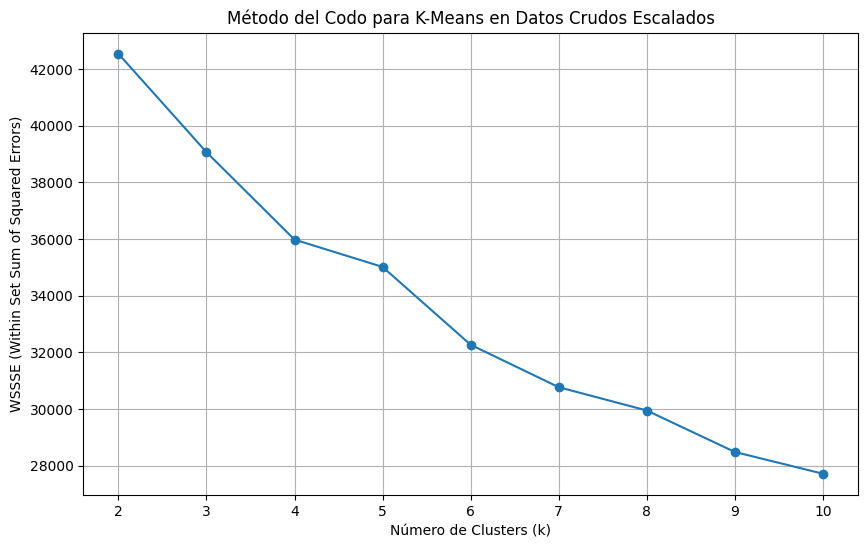

In [21]:
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

# Rango de valores de k a probar
max_k = 10
wssse_values = []

for k_val in range(2, max_k + 1):
    kmeans = KMeans(featuresCol='scaledFeatures', k=k_val, seed=1)
    model = kmeans.fit(white_df_scaled)
    # CORRECCIÓN: Usar model.summary.trainingCost en lugar de model.computeCost
    wssse = model.summary.trainingCost
    wssse_values.append(wssse)
    print(f"k={k_val}, WSSSE={wssse}")

# Preparar los datos para el gráfico
ks = list(range(2, max_k + 1))

# Crear la figura para el gráfico
fig = plt.figure(figsize=(10, 6))
plt.plot(ks, wssse_values, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WSSSE (Within Set Sum of Squared Errors)')
plt.title('Método del Codo para K-Means en Datos Crudos Escalados')
plt.xticks(ks)
plt.grid(True)
plt.show()

Observa el gráfico de arriba. El 'codo' es el punto donde la curva se dobla más pronunciadamente. Ese valor de `k` es a menudo una buena elección. Una vez que hayas identificado un `k` óptimo, puedes ajustar el valor de `k` en la siguiente celda para aplicar K-Means con esa selección.

**Aplicar K-Means a los datos crudos preparados**

In [47]:

# 3. Aplicar K-Means al DataFrame escalado
k = 4 # Puedes ajustar el número de clusters (k)
kmeans_raw = KMeans(featuresCol='scaledFeatures', k=k, seed=1)
kmeans_raw_model = kmeans_raw.fit(white_df_scaled)

# Obtener los centros de los clusters
centers_raw = kmeans_raw_model.clusterCenters()
print("Centros de los Clusters (datos crudos):")
for center in centers_raw:
    print(center)

# Asignar cada punto a un cluster
white_df_clustered_raw = kmeans_raw_model.transform(white_df_scaled)
white_df_clustered_raw.groupBy("prediction").count().show()
white_df_clustered_raw.select("quality", "prediction", "scaledFeatures").show(5)

Centros de los Clusters (datos crudos):
[  7.93187576   3.14834933   3.64735237   0.91190476   7.44524849
   2.36157036   3.39014889 332.47193725  20.50620068   4.069946
   7.77360251]
[  7.37263151   2.75275944   2.38483111   0.66393292   1.82566075
   1.85463759   2.87964407 331.69617883  21.90441535   4.52714869
   9.05435994]
[  8.260568     2.78804212   2.9671724    2.26793428   2.24093742
   2.7283772    4.07686076 333.39905483  20.91793744   4.36600029
   7.71206883]
[  8.81117504   2.70883173   2.87692644   0.78099566   1.83479901
   1.54605662   2.71292348 331.85221524  20.50844291   3.96196313
   8.99607128]
+----------+-----+
|prediction|count|
+----------+-----+
|         1| 1628|
|         3| 1466|
|         2| 1697|
|         0|  107|
+----------+-----+

+-------+----------+--------------------+
|quality|prediction|      scaledFeatures|
+-------+----------+--------------------+
|      6|         2|[8.29513396799212...|
|      6|         1|[7.46562057119291...|
|      6|  

**Preparación de datos para K-Means en PySpark (scores PCA)**

Cuando existen muchas variables de ruido en el conjunto de datos, es mejor primero reducir la dimensionalidad y capturar la mayor parte de la varianza antes de aplicar K-means. Para ello aplicaremos Análisis de Componentes Principales (PCA) a los datos escalados. Nuestro objetivo es seleccionar un número de componentes que expliquen al menos el 90% de la varianza total.

In [41]:
from pyspark.ml.feature import PCA
import numpy as np

# 1. Aplicar PCA a las características escaladas
# Inicialmente, elegimos un número de componentes cercano al total de características
# para poder analizar la varianza explicada.
num_components = len(feature_columns) # Número máximo de componentes = número de características
pca = PCA(k=num_components, inputCol="scaledFeatures", outputCol="pcaFeatures")
pca_model = pca.fit(white_df_scaled)

# Obtener y analizar la varianza explicada
explained_variance = pca_model.explainedVariance
print("Varianza explicada por cada componente:", explained_variance)

cumulative_variance = np.cumsum(explained_variance.toArray())
print("Varianza acumulada explicada:", cumulative_variance)

# Encontrar el número de componentes que explican al menos el 90% de la varianza
k_for_90_percent_variance = np.where(cumulative_variance >= 0.90)[0][0] + 1
print(f"Número de componentes para > 80% de varianza explicada: {k_for_90_percent_variance}")

# Re-ejecutar PCA con el número óptimo de componentes (si es diferente del inicial)
if k_for_90_percent_variance < num_components:
    print(f"Re-ejecutando PCA con k={k_for_90_percent_variance} componentes.")
    pca_optimal = PCA(k=k_for_80_percent_variance, inputCol="scaledFeatures", outputCol="pcaFeatures")
    pca_model_optimal = pca_optimal.fit(white_df_scaled)
    white_df_pca = pca_model_optimal.transform(white_df_scaled)
else:
    print(f"El número inicial de componentes ({num_components}) ya es óptimo o menor que el necesario. Usando el modelo PCA original.")
    white_df_pca = pca_model.transform(white_df_scaled)

white_df_pca.select("pcaFeatures").show(5, truncate=False)

#

Varianza explicada por cada componente: [0.2929321718756479,0.14320363009825193,0.11106103089581466,0.09259294133368026,0.08848496178773992,0.08534013740296914,0.0660543657226409,0.05448713451300153,0.03764942415870054,0.02631701259720769,0.001877189614345761]
Varianza acumulada explicada: [0.29293217 0.4361358  0.54719683 0.63978977 0.72827474 0.81361487
 0.87966924 0.93415637 0.9718058  0.99812281 1.        ]
Número de componentes para > 80% de varianza explicada: 8
Re-ejecutando PCA con k=8 componentes.
+---------------------------------------------------------------------------------------------------------------------+
|pcaFeatures                                                                                                          |
+---------------------------------------------------------------------------------------------------------------------+
|[-172.030781010491,10.280562795493287,-37.1840592441701,4.08072629849892,21.724326180993156,-112.49093389378436]     |
|[-167.7

**Aplicar K-Means a los scores PCA**

In [48]:
# 2. Aplicar K-Means a los datos transformados por PCA
k = 4 # Puedes ajustar el número de clusters (k)
kmeans_pca = KMeans(featuresCol='pcaFeatures', k=k, seed=1)
kmeans_pca_model = kmeans_pca.fit(white_df_pca)

# Obtener los centros de los clusters
centers_pca = kmeans_pca_model.clusterCenters()
print("Centros de los Clusters (scores PCA):")
for center in centers_pca:
    print(center)

# Asignar cada punto a un cluster
white_df_clustered_pca = kmeans_pca_model.transform(white_df_pca)
white_df_clustered_pca.groupBy("prediction").count().show()
white_df_clustered_pca.select("quality", "prediction", "pcaFeatures").show(5)

Centros de los Clusters (scores PCA):
[-170.43762212   10.95381799  -36.42852933    3.07311747   21.42166946
 -111.57248407]
[-167.76663704   11.77087889  -35.56232601    2.66746368   21.68142611
 -111.90154693]
[-166.39911387   11.16784785  -36.89784884    3.0861761    21.0893106
 -111.34410507]
[-167.68863634    9.41914785  -36.10818246    2.90991153   21.50490188
 -111.5693343 ]
+----------+-----+
|prediction|count|
+----------+-----+
|         1| 1114|
|         3| 1143|
|         2| 1012|
|         0| 1629|
+----------+-----+

+-------+----------+--------------------+
|quality|prediction|         pcaFeatures|
+-------+----------+--------------------+
|      6|         0|[-172.03078101049...|
|      6|         1|[-167.70969084511...|
|      6|         3|[-168.50948757128...|
|      6|         0|[-169.80943838847...|
|      6|         0|[-169.80943838847...|
+-------+----------+--------------------+
only showing top 5 rows


**Evaluación de la Calidad de Clusters: Silhouette Score**

El Silhouette Score es una métrica utilizada para evaluar la calidad de los clusters. Un valor más alto indica que los objetos están bien emparejados con su propio cluster y mal emparejados con clusters vecinos. El score varía de -1 a +1, donde:
*   **+1:** Indica que el objeto está muy bien asignado a su propio cluster.
*   **0:** Indica que el objeto está en el límite entre dos clusters.
*   **-1:** Indica que el objeto ha sido asignado al cluster incorrecto.

In [49]:
from pyspark.ml.evaluation import ClusteringEvaluator

# --- Evaluar el modelo con datos crudos escalados ---
# Inicializar el evaluador de clusters para el modelo de datos crudos
evaluator_raw = ClusteringEvaluator(featuresCol='scaledFeatures', metricName='silhouette', distanceMeasure='squaredEuclidean')
silhouette_raw = evaluator_raw.evaluate(white_df_clustered_raw)
print(f"Silhouette Score (Datos Crudos): {silhouette_raw}")

# --- Evaluar el modelo con scores PCA ---
# Inicializar el evaluador de clusters para el modelo PCA
evaluator_pca = ClusteringEvaluator(featuresCol='pcaFeatures', metricName='silhouette', distanceMeasure='squaredEuclidean')
silhouette_pca = evaluator_pca.evaluate(white_df_clustered_pca)
print(f"Silhouette Score (Scores PCA): {silhouette_pca}")

Silhouette Score (Datos Crudos): 0.26770090511185174
Silhouette Score (Scores PCA): 0.2588998043753344


Estos scores te darán una idea de cuán coherentes son los clusters formados por cada enfoque. Utilizar primero una reducción de dimensionalidad no mejora la calidad de los clústers en este caso, con este número de clusters.

**Interpretar los clústers: perfiles**

Revisemos primero las cargas de los dos primeros PC para capturar las variables que explican más la variabilidad de los datos

In [40]:
import pandas as pd

# El modelo PCA final es 'pca_model' o 'pca_model_optimal'
# Asegurémonos de usar el que tiene el número óptimo de componentes
final_pca_model = pca_model_optimal if 'pca_model_optimal' in locals() else pca_model

# Extraer las cargas (eigenvectores) del modelo PCA
loadings_matrix = final_pca_model.pc.toArray()

# Usaremos solo los primeros dos componentes para visualizar sus cargas
# Y las 'feature_columns' que definimos al inicio

# Crear un DataFrame para visualizar las cargas más fácilmente
loadings_df = pd.DataFrame(
    loadings_matrix[:, :2], # Seleccionar solo los dos primeros componentes
    columns=[f"PC{i+1}" for i in range(2)], # Nombres de las columnas PC1, PC2
    index=feature_columns # Usar las columnas de características originales como índice
)

print("Cargas de los dos Primeros Componentes Principales:")
display(loadings_df)

Cargas de los dos Primeros Componentes Principales:


,PC1,PC2
fixed acidity,-0.157218,-0.587558
volatile acidity,-0.005089,0.051728
citric acid,-0.144050,-0.345295
residual sugar,-0.427408,0.008749
chlorides,-0.212011,-0.008800
free sulfur dioxide,-0.300334,0.290355
total sulfur dioxide,-0.406652,0.244032
density,-0.511524,0.006297
pH,0.128832,0.581344
sulphates,-0.043379,0.222695


Para comprender mejor las características de cada cluster, calcularemos el **contenido promedio de densidad, alcohol, azucar residual, PH y acidez fija** de los vinos asignados a cada uno. Esto puede revelar patrones interesantes y diferenciar los clusters en función de esta importante característica del vino.

In [52]:
from pyspark.sql.functions import avg

print("\n--- Contenido Promedio de Densidad por Cluster (Scores PCA) ---")
white_df_clustered_raw.groupBy("prediction") \
                      .agg(avg("density").alias("average_density")) \
                      .orderBy("prediction") \
                      .show()

print("\n--- Contenido Promedio de Alcohol por Cluster (Scores PCA) ---")
white_df_clustered_raw.groupBy("prediction") \
                      .agg(avg("alcohol").alias("average_alcohol")) \
                      .orderBy("prediction") \
                      .show()

print("\n--- Contenido Promedio de Azúcar Residual por Cluster (Scores PCA) ---")
white_df_clustered_raw.groupBy("prediction") \
                      .agg(avg("residual sugar").alias("average_rsugar")) \
                      .orderBy("prediction") \
                      .show()

print("\n--- Contenido Promedio de pH por Cluster (Scores PCA) ---")
white_df_clustered_raw.groupBy("prediction") \
                      .agg(avg("pH").alias("average_pH")) \
                      .orderBy("prediction") \
                      .show()

print("\n--- Contenido Promedio de Acidez fija por Cluster (Scores PCA) ---")
white_df_clustered_raw.groupBy("prediction") \
                      .agg(avg("fixed acidity").alias("average_f_acidity")) \
                      .orderBy("prediction") \
                      .show()


--- Contenido Promedio de Densidad por Cluster (Scores PCA) ---
+----------+------------------+
|prediction|   average_density|
+----------+------------------+
|         0|0.9943926168224297|
|         1|0.9920723955773966|
|         2|0.9971655391867992|
|         3|0.9925390859481579|
+----------+------------------+


--- Contenido Promedio de Alcohol por Cluster (Scores PCA) ---
+----------+------------------+
|prediction|   average_alcohol|
+----------+------------------+
|         0| 9.566355140186914|
|         1| 11.14248157248159|
|         2| 9.490630524454913|
|         3|11.070750341064107|
+----------+------------------+


--- Contenido Promedio de Azúcar Residual por Cluster (Scores PCA) ---
+----------+------------------+
|prediction|    average_rsugar|
+----------+------------------+
|         0| 4.625233644859812|
|         1|3.3675061425061474|
|         2|11.503093694755483|
|         3|3.9612551159617944|
+----------+------------------+


--- Contenido Promedio de p

Se puede realizar lo mismo **con otras variables de interés para perfilar los grupos**

**Visualización de Clusters en los Primeros Dos Componentes Principales**

Para visualizar la separación de los clusters, representaremos los vinos en un gráfico de dispersión utilizando los dos primeros componentes principales (PC1 y PC2). Cada punto en el gráfico será un vino y estará coloreado según el cluster al que fue asignado.

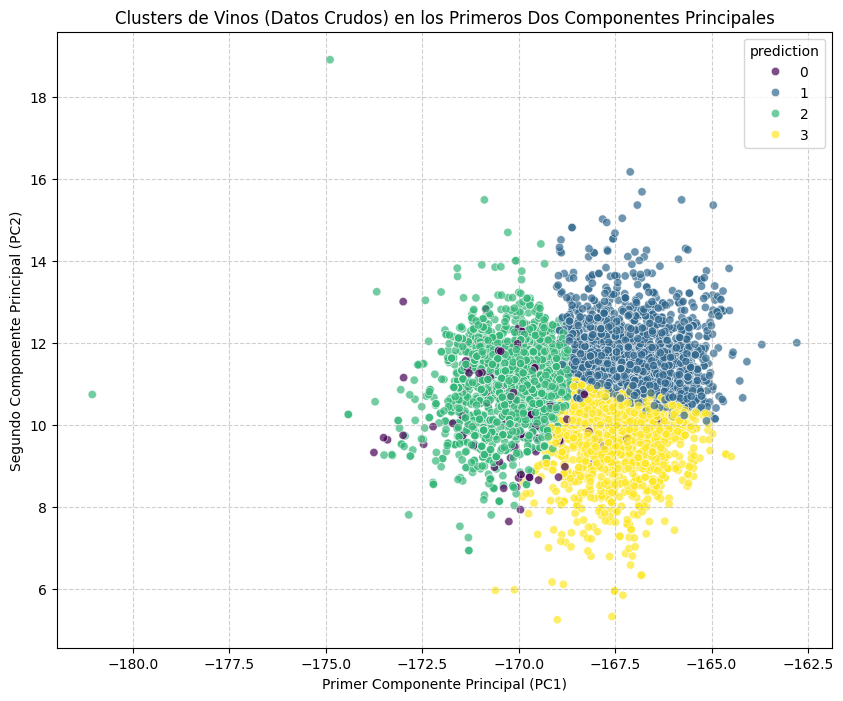

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType

# Asegurarse de que el modelo PCA óptimo esté disponible
# final_pca_model fue definido en la celda DG9XMscoxPu3
final_pca_model = pca_model_optimal if 'pca_model_optimal' in locals() else pca_model

# Aplicar PCA a white_df_clustered_raw para obtener pcaFeatures
white_df_clustered_raw_with_pca_features = final_pca_model.transform(white_df_clustered_raw)

# Crear UDFs para extraer los dos primeros componentes de pcaFeatures
first_pc_udf = udf(lambda v: float(v[0]), DoubleType())
second_pc_udf = udf(lambda v: float(v[1]), DoubleType())

# Añadir las columnas de los dos primeros componentes al DataFrame
white_df_clustered_raw_plot = white_df_clustered_raw_with_pca_features \
    .withColumn("PC1", first_pc_udf(col("pcaFeatures"))) \
    .withColumn("PC2", second_pc_udf(col("pcaFeatures")))

# Convertir a Pandas DataFrame para facilitar la visualización con seaborn
pandas_df_for_plot = white_df_clustered_raw_plot.select("PC1", "PC2", "prediction", "quality").toPandas()

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="prediction",
    palette="viridis", # Puedes elegir otra paleta de colores
    data=pandas_df_for_plot,
    legend="full",
    alpha=0.7
)
plt.title('Clusters de Vinos (Datos Crudos) en los Primeros Dos Componentes Principales')
plt.xlabel('Primer Componente Principal (PC1)')
plt.ylabel('Segundo Componente Principal (PC2)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Proceso de Classificación en PySpark: Naive Bayes para la Calidad del Vino

En esta sección, aplicaremos un modelo de clasificación para predecir la calidad del vino (`quality`) utilizando el algoritmo Naive Bayes. Este modelo es adecuado para datos categóricos y también puede manejar datos continuos si se asumen distribuciones específicas (como la Gaussiana).


**Preparación de Datos para Clasificación**

Para el modelo de clasificación, necesitamos asegurarnos de que las características estén en el formato de vector y que la columna objetivo (`quality`) sea tratada como una etiqueta. Dado que Naive Bayes espera etiquetas numéricas, usaremos directamente la columna `quality` que ya es `integer`.

In [54]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Definir las columnas de características (las mismas que usamos para el clustering)
feature_columns_clf = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

# Ensamblar las características en un solo vector
assembler_clf = VectorAssembler(inputCols=feature_columns_clf, outputCol="features_clf")
white_df_assembled_clf = assembler_clf.transform(white_df)

# Renombrar la columna 'quality' a 'label' para que sea compatible con los estimadores de MLlib
white_df_final_clf = white_df_assembled_clf.withColumnRenamed("quality", "label")

print("Esquema del DataFrame final para clasificación:")
white_df_final_clf.printSchema()
white_df_final_clf.select("features_clf", "label").show(5, truncate=False)

Esquema del DataFrame final para clasificación:
root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- label: integer (nullable = true)
 |-- color: string (nullable = false)
 |-- features_clf: vector (nullable = true)

+--------------------------------------------------------+-----+
|features_clf                                            |label|
+--------------------------------------------------------+-----+
|[7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8]|6    |
|[6.3,0.3,0.34,1.6,0.049,14.0,132.0,0.994,3.3,0.49,9.5]  |6    |
|[8.1,0.28,0.4,6.9,0.0

**División del Conjunto de Datos**

Dividiremos el conjunto de datos en un 80% para entrenamiento y un 20% para prueba para evaluar el rendimiento del modelo.

In [55]:
# Dividir los datos en conjuntos de entrenamiento y prueba
(trainingData, testData) = white_df_final_clf.randomSplit([0.8, 0.2], seed=42)

print(f"Número de registros para entrenamiento: {trainingData.count()}")
print(f"Número de registros para prueba: {testData.count()}")

Número de registros para entrenamiento: 3961
Número de registros para prueba: 937


**Entrenamiento del Modelo Naive Bayes**

Ahora entrenaremos el modelo de Naive Bayes utilizando los datos de entrenamiento. Utilizaremos el modelo Gaussiano de Naive Bayes, que es común para características continuas.

In [56]:
# Crear una instancia de NaiveBayes
# El parámetro 'modelType' puede ser 'multinomial', 'bernoulli' o 'gaussian'
# 'gaussian' es adecuado para características continuas.
nb = NaiveBayes(modelType="gaussian", featuresCol="features_clf", labelCol="label")

# Entrenar el modelo NaiveBayes
nb_model = nb.fit(trainingData)

print("Modelo Naive Bayes entrenado.")

Modelo Naive Bayes entrenado.


**4.4 Evaluación del Modelo Naive Bayes**

Evaluaremos el modelo utilizando el conjunto de prueba para calcular métricas como la precisión (accuracy) y la F1-Score, que son comunes para problemas de clasificación multiclase. También mostraremos una matriz de confusión para entender la distribución de las predicciones.

In [58]:
from pyspark.sql.functions import col

# Realizar predicciones sobre el conjunto de prueba
predictions = nb_model.transform(testData)

# Mostrar algunas predicciones
print("Algunas predicciones del modelo Naive Bayes:")
predictions.select("label", "prediction", "probability").show(10, truncate=False)

# Evaluar el modelo
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator_accuracy.evaluate(predictions)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")
f1_score = evaluator_f1.evaluate(predictions)

# Añadir evaluador para Precision
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision = evaluator_precision.evaluate(predictions)

# Añadir evaluador para Recall
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall")
recall = evaluator_recall.evaluate(predictions)

print(f"Precisión (Accuracy) del modelo Naive Bayes: {accuracy}")
print(f"F1-Score del modelo Naive Bayes: {f1_score}")
print(f"Precision Ponderada del modelo Naive Bayes: {precision}")
print(f"Recall Ponderado del modelo Naive Bayes: {recall}")

# Matriz de Confusión
print("\nMatriz de Confusión:")
confusion_matrix = predictions.groupBy("label").pivot("prediction").count().orderBy("label").fillna(0)
confusion_matrix.show()

Algunas predicciones del modelo Naive Bayes:
+-----+----------+---------------------------------------------------------------------------------------------------------------------------------------------------+
|label|prediction|probability                                                                                                                                        |
+-----+----------+---------------------------------------------------------------------------------------------------------------------------------------------------+
|7    |5.0       |[0.1742763633424874,0.0017216204286440012,3.967611960838043E-5,0.03596874999960259,0.017331728249944466,0.7706618618597132,1.5455273541286503E-47] |
|7    |1.0       |[0.0015423267227778015,0.5669545990697991,0.007106756514415105,0.07573170028205421,0.04537450235297377,0.30329011505798004,1.1352062563771175E-35] |
|5    |1.0       |[6.489993108886439E-4,0.9046856724587935,0.04933027512427521,0.04437963295222837,1.9258445408966323E-4

### Proceso de Clasificación en PySpark: Decision Tree Classifier para la Calidad del Vino

Dado el bajo rendimiento del modelo Naive Bayes, exploraremos ahora el `DecisionTreeClassifier`. Los árboles de decisión son modelos no paramétricos que pueden capturar relaciones complejas en los datos y a menudo ofrecen una mejor interpretabilidad.

In [59]:
from pyspark.ml.classification import DecisionTreeClassifier

# Crear una instancia de DecisionTreeClassifier
# featuresCol y labelCol ya están definidos en white_df_final_clf
dt = DecisionTreeClassifier(featuresCol="features_clf", labelCol="label", seed=42)

# Entrenar el modelo DecisionTreeClassifier
decision_tree_model = dt.fit(trainingData)

print("Modelo Decision Tree Classifier entrenado.")

Modelo Decision Tree Classifier entrenado.


**Evaluación del Modelo Decision Tree Classifier**

Ahora evaluaremos el rendimiento del `DecisionTreeClassifier` utilizando las mismas métricas (Accuracy, F1-Score, Precision y Recall) y la matriz de confusión para comparar con el modelo Naive Bayes.

In [60]:
from pyspark.sql.functions import col
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Realizar predicciones sobre el conjunto de prueba
predictions_dt = decision_tree_model.transform(testData)

# Mostrar algunas predicciones
print("Algunas predicciones del modelo Decision Tree Classifier:")
predictions_dt.select("label", "prediction", "probability").show(10, truncate=False)

# Evaluar el modelo
evaluator_accuracy_dt = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy_dt = evaluator_accuracy_dt.evaluate(predictions_dt)

evaluator_f1_dt = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")
f1_score_dt = evaluator_f1_dt.evaluate(predictions_dt)

evaluator_precision_dt = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision_dt = evaluator_precision_dt.evaluate(predictions_dt)

evaluator_recall_dt = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall")
recall_dt = evaluator_recall_dt.evaluate(predictions_dt)

print(f"\nPrecisión (Accuracy) del modelo Decision Tree: {accuracy_dt}")
print(f"F1-Score del modelo Decision Tree: {f1_score_dt}")
print(f"Precision Ponderada del modelo Decision Tree: {precision_dt}")
print(f"Recall Ponderado del modelo Decision Tree: {recall_dt}")

# Matriz de Confusión
print("\nMatriz de Confusión para Decision Tree:")
confusion_matrix_dt = predictions_dt.groupBy("label").pivot("prediction").count().orderBy("label").fillna(0)
confusion_matrix_dt.show()

Algunas predicciones del modelo Decision Tree Classifier:
+-----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|prediction|probability                                                                                                                                                  |
+-----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------+
|7    |7.0       |[0.0,0.0,0.0,0.0,0.0,0.06666666666666667,0.13333333333333333,0.7333333333333333,0.06666666666666667,0.0]                                                     |
|7    |7.0       |[0.0,0.0,0.0,0.0029069767441860465,0.0029069767441860465,0.040697674418604654,0.2936046511627907,0.5203488372093024,0.13372093023255813,0.005813953488372093]|
|5    |6.0       |[0.0,0.0,0.0,0.013333333333333334,0.12,

### Proceso de Clasificación en PySpark: RandomForestClassifier para la Calidad del Vino

El `RandomForestClassifier` es un algoritmo de aprendizaje en conjunto que construye múltiples árboles de decisión y combina sus predicciones para obtener un resultado más preciso y robusto. Es una excelente opción para mejorar el rendimiento de clasificación.

In [61]:
from pyspark.ml.classification import RandomForestClassifier

# Crear una instancia de RandomForestClassifier
# featuresCol y labelCol ya están definidos en white_df_final_clf
# numTrees es el número de árboles en el bosque
rf = RandomForestClassifier(featuresCol="features_clf", labelCol="label", numTrees=100, seed=42)

# Entrenar el modelo RandomForestClassifier
random_forest_model = rf.fit(trainingData)

print("Modelo RandomForest Classifier entrenado.")

Modelo RandomForest Classifier entrenado.


**Evaluación del Modelo RandomForestClassifier**

Ahora evaluaremos el rendimiento del `RandomForestClassifier` utilizando las mismas métricas (Accuracy, F1-Score, Precision y Recall) y la matriz de confusión para comparar con los modelos Naive Bayes y Decision Tree.

In [62]:
from pyspark.sql.functions import col
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Realizar predicciones sobre el conjunto de prueba
predictions_rf = random_forest_model.transform(testData)

# Mostrar algunas predicciones
print("Algunas predicciones del modelo RandomForest Classifier:")
predictions_rf.select("label", "prediction", "probability").show(10, truncate=False)

# Evaluar el modelo
evaluator_accuracy_rf = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy_rf = evaluator_accuracy_rf.evaluate(predictions_rf)

evaluator_f1_rf = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")
f1_score_rf = evaluator_f1_rf.evaluate(predictions_rf)

evaluator_precision_rf = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision_rf = evaluator_precision_rf.evaluate(predictions_rf)

evaluator_recall_rf = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall")
recall_rf = evaluator_recall_rf.evaluate(predictions_rf)

print(f"\nPrecisión (Accuracy) del modelo RandomForest: {accuracy_rf}")
print(f"F1-Score del modelo RandomForest: {f1_score_rf}")
print(f"Precision Ponderada del modelo RandomForest: {precision_rf}")
print(f"Recall Ponderado del modelo RandomForest: {recall_rf}")

# Matriz de Confusión
print("\nMatriz de Confusión para RandomForest:")
confusion_matrix_rf = predictions_rf.groupBy("label").pivot("prediction").count().orderBy("label").fillna(0)
confusion_matrix_rf.show()

Algunas predicciones del modelo RandomForest Classifier:
+-----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|prediction|probability                                                                                                                                                  |
+-----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------+
|7    |7.0       |[0.0,0.0,0.0,0.001574279917824304,0.007552604689076516,0.07026485875742351,0.373669834428415,0.4187874593387462,0.12560088076874376,0.0025500820997706214]   |
|7    |7.0       |[0.0,0.0,0.0,0.002004338221484762,0.02625158361478697,0.0832774536043877,0.34538406878239786,0.4339467497456057,0.10623928242409082,0.0028965236072461217]   |
|5    |5.0       |[0.0,0.0,0.0,0.013725310407043181,0.1230

**Tuning de Hiperparámetros con CrossValidator para RandomForest**

Para optimizar aún más el rendimiento del `RandomForestClassifier`, realizaremos un tuning de hiperparámetros utilizando `CrossValidator`. Esto nos permitirá buscar la mejor combinación de parámetros (`numTrees` y `maxDepth`) que maximice la métrica de evaluación (en este caso, la precisión).

In [63]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Definir el modelo base (RandomForestClassifier)
# Ya lo tenemos instanciado como 'rf' desde la celda anterior.
# rf = RandomForestClassifier(featuresCol="features_clf", labelCol="label", seed=42)

# 2. Crear una cuadrícula de parámetros a buscar
# Vamos a probar diferentes números de árboles y profundidades máximas
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50, 100]) \
    .addGrid(rf.maxDepth, [5, 10, 15]) \
    .build()

# 3. Configurar el evaluador
# Usaremos la precisión como métrica principal para seleccionar el mejor modelo
evaluator_cv = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# 4. Crear el CrossValidator
# Especificamos el estimador (modelo), la cuadrícula de parámetros y el evaluador.
# numFolds = 3 significa que dividiremos los datos de entrenamiento en 3 partes
# para la validación cruzada.
cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_cv,
    numFolds=3, # Usamos 3 folds para un cálculo más rápido, se recomienda 5 o 10
    seed=42
)

# 5. Entrenar el modelo con CrossValidator
print("Iniciando entrenamiento con CrossValidator...")
cv_model = cv.fit(trainingData)
print("Entrenamiento con CrossValidator completado.")

# Obtener el mejor modelo encontrado por el CrossValidator
best_rf_model = cv_model.bestModel

print(f"Mejor número de árboles: {best_rf_model.getNumTrees}")
print(f"Mejor profundidad máxima: {best_rf_model.getMaxDepth()}")

Iniciando entrenamiento con CrossValidator...
Entrenamiento con CrossValidator completado.
Mejor número de árboles: 100
Mejor profundidad máxima: 15


**Evaluación del Mejor Modelo RandomForest con Tuning de Hiperparámetros**

Ahora evaluaremos el rendimiento del `RandomForestClassifier` óptimo encontrado por el `CrossValidator` utilizando las mismas métricas que antes (Accuracy, F1-Score, Precision y Recall) y la matriz de confusión. Esto nos permitirá ver la mejora con respecto al modelo sin tuning.

In [64]:
from pyspark.sql.functions import col

# Realizar predicciones sobre el conjunto de prueba con el mejor modelo
predictions_tuned_rf = best_rf_model.transform(testData)

# Mostrar algunas predicciones
print("Algunas predicciones del modelo RandomForest Tuned:")
predictions_tuned_rf.select("label", "prediction", "probability").show(10, truncate=False)

# Evaluar el modelo tuned
accuracy_tuned_rf = evaluator_cv.evaluate(predictions_tuned_rf)

evaluator_f1_tuned_rf = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")
f1_score_tuned_rf = evaluator_f1_tuned_rf.evaluate(predictions_tuned_rf)

evaluator_precision_tuned_rf = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision_tuned_rf = evaluator_precision_tuned_rf.evaluate(predictions_tuned_rf)

evaluator_recall_tuned_rf = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall")
recall_tuned_rf = evaluator_recall_tuned_rf.evaluate(predictions_tuned_rf)

print(f"\nPrecisión (Accuracy) del modelo RandomForest Tuned: {accuracy_tuned_rf}")
print(f"F1-Score del modelo RandomForest Tuned: {f1_score_tuned_rf}")
print(f"Precision Ponderada del modelo RandomForest Tuned: {precision_tuned_rf}")
print(f"Recall Ponderado del modelo RandomForest Tuned: {recall_tuned_rf}")

# Matriz de Confusión
print("\nMatriz de Confusión para RandomForest Tuned:")
confusion_matrix_tuned_rf = predictions_tuned_rf.groupBy("label").pivot("prediction").count().orderBy("label").fillna(0)
confusion_matrix_tuned_rf.show()

Algunas predicciones del modelo RandomForest Tuned:
+-----+----------+------------------------------------------------------------------------------------------------------------------------------------------+
|label|prediction|probability                                                                                                                               |
+-----+----------+------------------------------------------------------------------------------------------------------------------------------------------+
|7    |7.0       |[0.0,0.0,0.0,0.0,0.0,0.08875,0.1658397435897436,0.4054102564102564,0.34,0.0]                                                              |
|7    |7.0       |[0.0,0.0,0.0,0.0,0.09,0.10152361604875573,0.3036092771288302,0.35406128322329444,0.1508058235991197,0.0]                                  |
|5    |5.0       |[0.0,0.0,0.0,0.0,0.2909090909090909,0.4290909090909091,0.21,0.07,0.0,0.0]                                                                 |
